<a href="https://colab.research.google.com/github/SoumitroDas/Pneumonia-Detection-from-Chest-Xray-CNN/blob/Smain/Pneumonia_ChestXray_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload() #upload kaggle api

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"soumitrokumardas","key":"9883b58845b549055918b85081bc33c5"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d tolgadincer/labeled-chest-xray-images

Dataset URL: https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images
License(s): other
 99% 1.16G/1.17G [00:11<00:00, 70.8MB/s]
100% 1.17G/1.17G [00:11<00:00, 109MB/s] 


In [4]:
!unzip labeled-chest-xray-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/NORMAL-2558319-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2558319-0002.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2559035-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2559035-0002.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2565226-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2568157-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2597757-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2597757-0002.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-263932-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2646645-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2646923-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2655558-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2659844-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2675017-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2675017-00

In [5]:
!ls

chest_xray  kaggle.json  labeled-chest-xray-images.zip	sample_data


In [6]:
!pip install tensorflow

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
tf.__version__

'2.19.0'

Augmentation

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.1,
    shear_range= 0.2
)

train_generator = train_datagen.flow_from_directory(
    '/content/chest_xray/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 5232 images belonging to 2 classes.


In [12]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/chest_xray/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [46]:
import glob
import cv2

Train Set - NORMAL samples


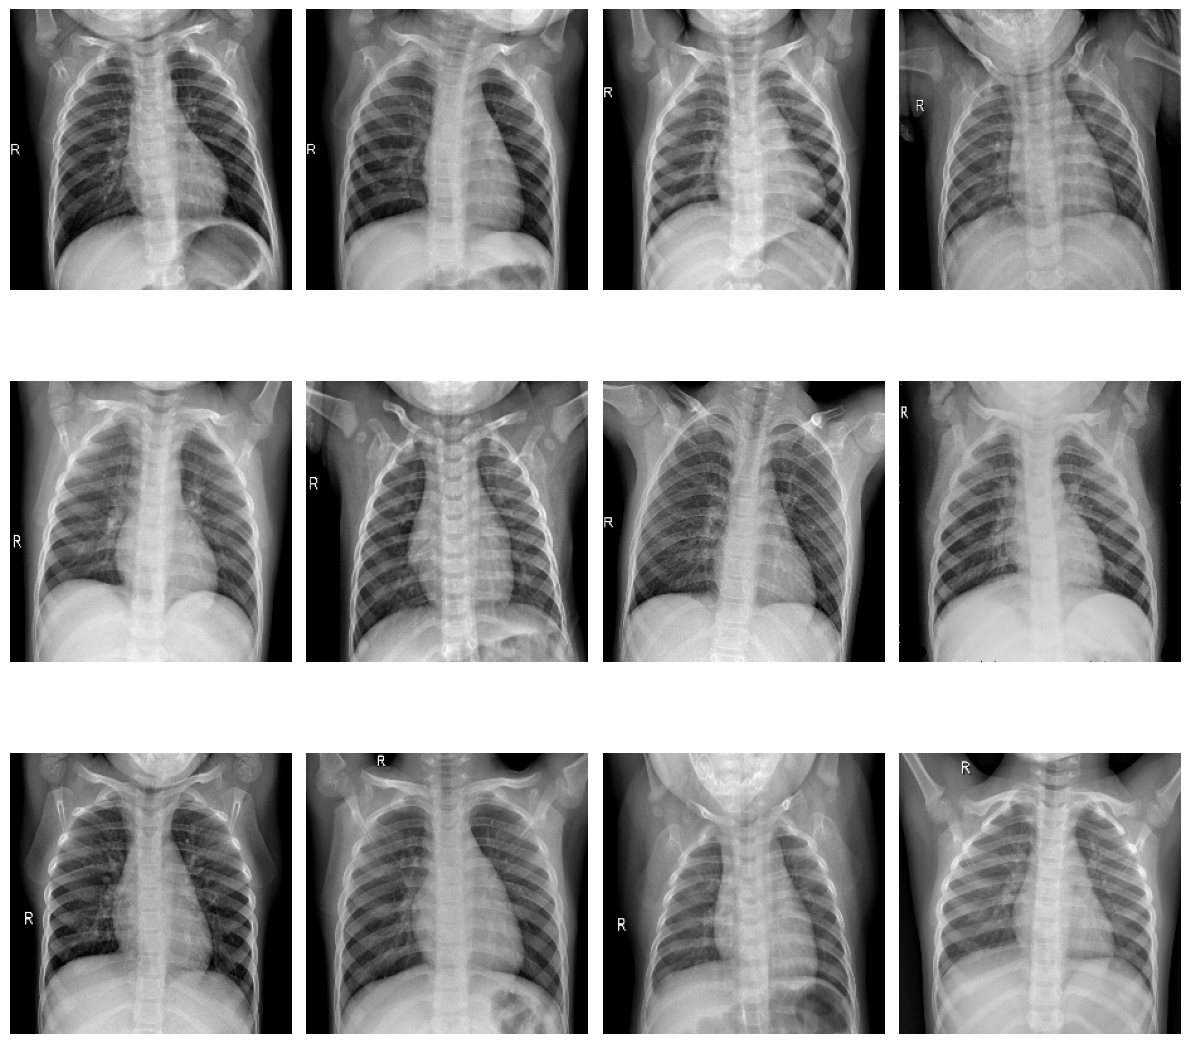

In [47]:
train_path = "/content/chest_xray/train"

train_normal = glob.glob(train_path + "/NORMAL/*.jpeg")
train_pneumonia = glob.glob(train_path + "/PNEUMONIA/*.jpeg")

print("Train Set - NORMAL samples")

plt.figure(figsize=(12, 12))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    img = cv2.imread(train_normal[i])

    # resize to the same size your CNN uses
    img = cv2.resize(img, (224, 224))

    # OpenCV loads in BGR → convert to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

CNN

In [14]:
cnn = tf.keras.models.Sequential()

In [15]:
cnn.add(tf.keras.layers.Conv2D(
    32, 3,
    activation='relu',
    input_shape=(224,224,3)
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

In [17]:
cnn.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))

In [18]:
cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

In [19]:
cnn.add(tf.keras.layers.Conv2D(128, (3,3), activation='relu'))

In [20]:
cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

In [21]:
cnn.add(tf.keras.layers.Flatten())

In [22]:
cnn.add(tf.keras.layers.Dense(128, activation='relu'))

In [23]:
cnn.add(tf.keras.layers.Dense(2, activation='softmax'))

Training CNN

In [24]:
cnn.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

In [25]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = cnn.fit( x= train_generator,
                  validation_data= test_generator,
                   epochs= 25
                )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 662s 4s/step - accuracy: 0.7850 - loss: 0.5309 - val_accuracy: 0.8494 - val_loss: 0.4642
Epoch 2/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 664s 4s/step - accuracy: 0.9418 - loss: 0.1423 - val_accuracy: 0.8622 - val_loss: 0.3906
Epoch 3/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 636s 4s/step - accuracy: 0.9569 - loss: 0.1167 - val_accuracy: 0.8718 - val_loss: 0.3699
Epoch 4/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 622s 4s/step - accuracy: 0.9443 - loss: 0.1383 - val_accuracy: 0.8654 - val_loss: 0.4389
Epoch 5/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 652s 4s/step - accuracy: 0.9626 - loss: 0.1035 - val_accuracy: 0.9054 - val_loss: 0.2993
Epoch 6/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 635s 4s/step - accuracy: 0.9632 - loss: 0.1049 - val_accuracy: 0.8974 - val_loss: 0.2835
Epoch 7/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 630s 4s/step - accuracy: 0.9643 - loss: 0.0956 - val_accuracy: 0.8494 - val_loss: 0.5448
Epoch 8/25
164/164 ━━━━━━━━━━━━━━━━━━━━ 681s 4s/step - accuracy: 0.9702 - loss: 0.0836 - val_accu

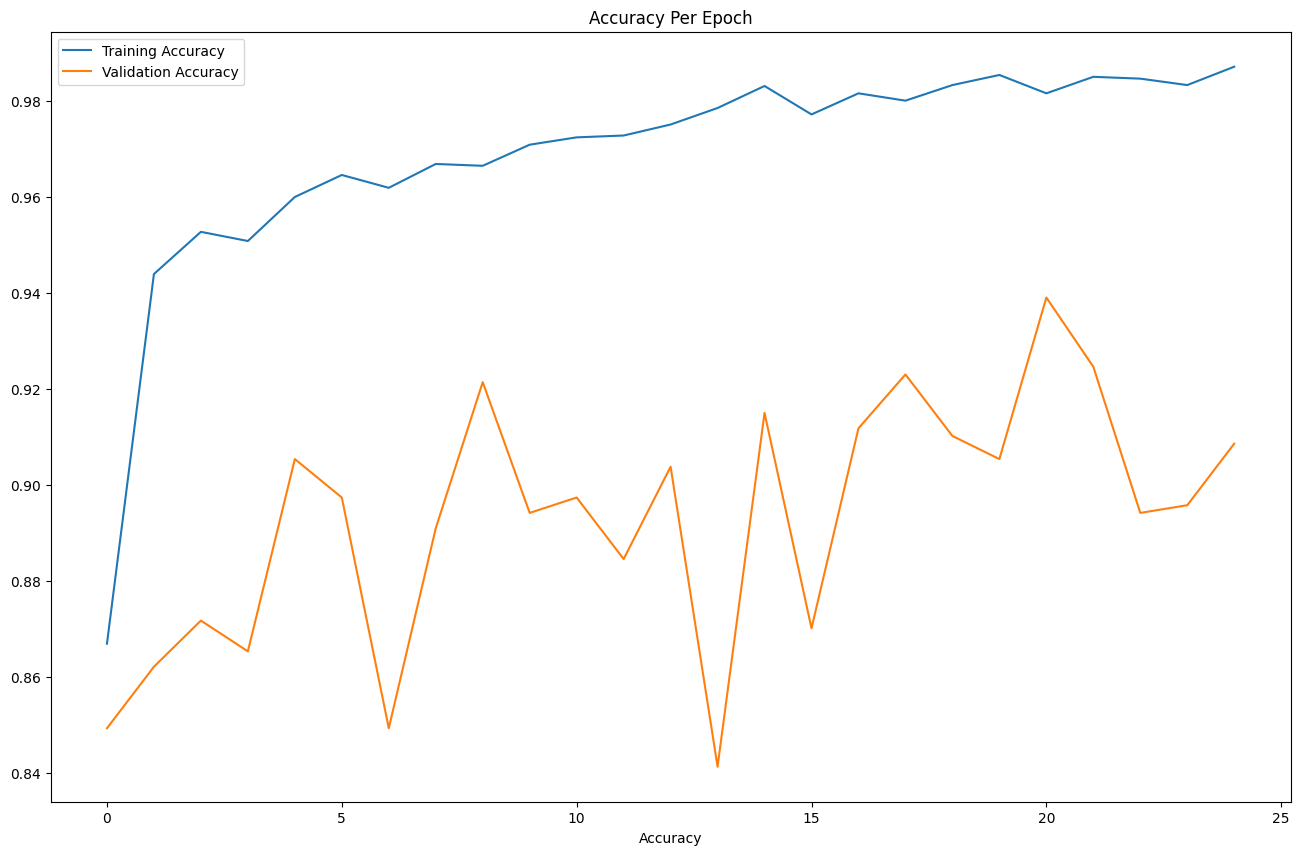

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.xlabel('Accuracy')
plt.title('Accuracy Per Epoch')
plt.legend()
plt.show()

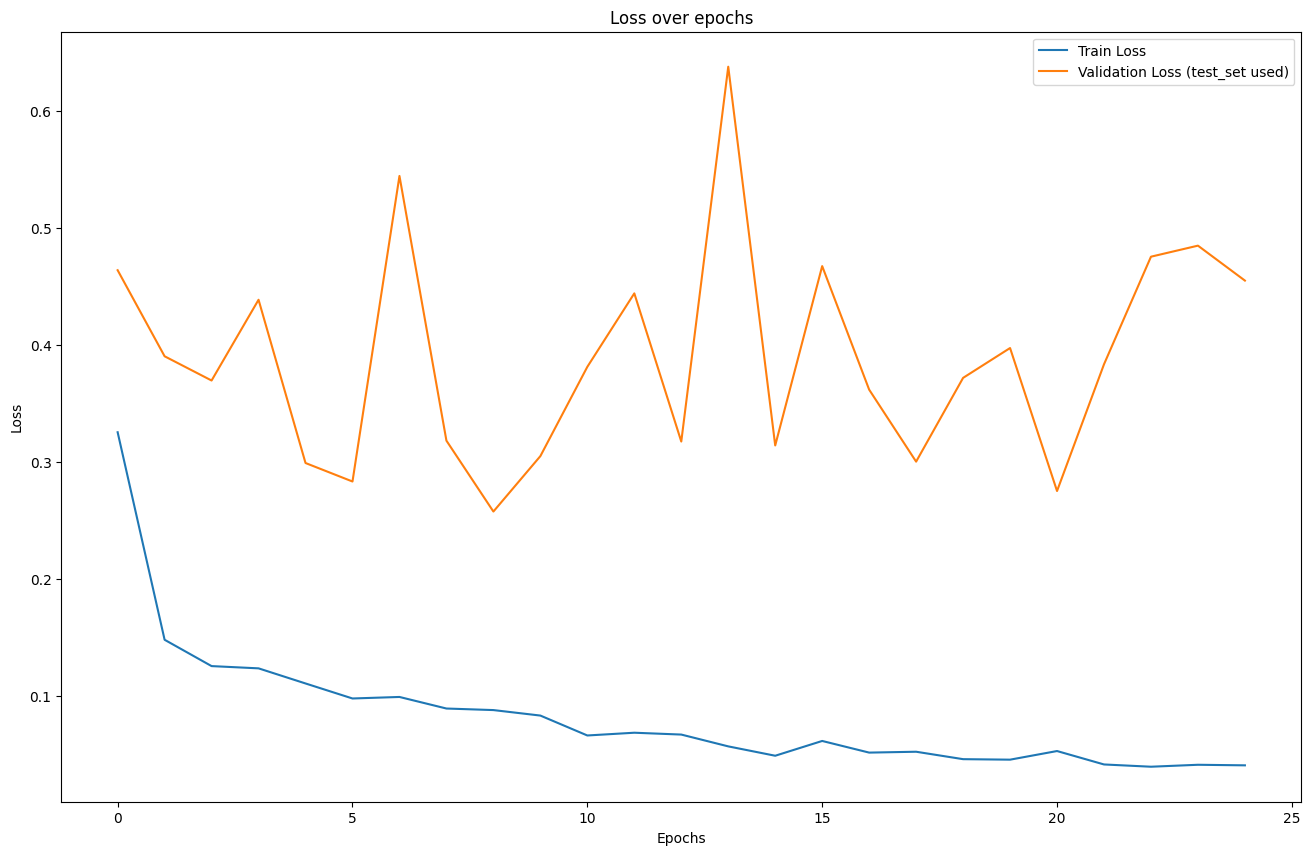

In [54]:
# Loss plot
plt.figure(figsize=(16, 10))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss (test_set used)')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [36]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

preds = cnn.predict(test_generator)
pred_classes = np.argmax(preds, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

20/20 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step


In [50]:
Confusion_Matrix=confusion_matrix(true_classes, pred_classes)
print("Confusion Matrix\n", Confusion_Matrix)
print("Classification Report\n", classification_report(true_classes, pred_classes, target_names=class_labels))

Confusion Matrix
 [[185  49]
 [  8 382]]
Classification Report
               precision    recall  f1-score   support

      NORMAL       0.96      0.79      0.87       234
   PNEUMONIA       0.89      0.98      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624



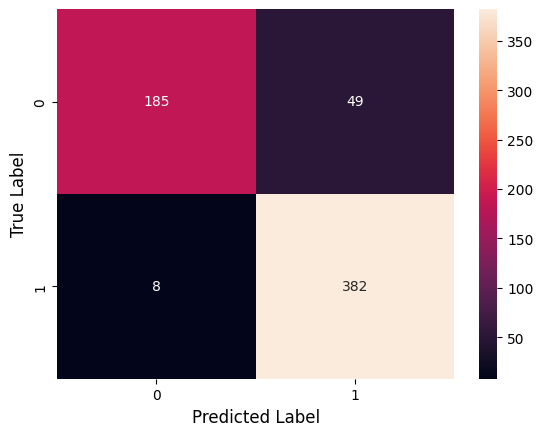

In [51]:
import seaborn as sns
sns.heatmap(Confusion_Matrix, annot=True, fmt="d")

plt.xlabel("Predicted Label", fontsize= 12)
plt.ylabel("True Label", fontsize= 12)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


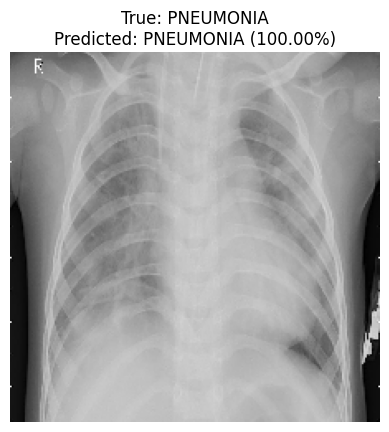

Actual label    : PNEUMONIA
Predicted label : PNEUMONIA
Confidence      : 0.99996924


In [43]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image

# image path
img_path = '/content/chest_xray/test/PNEUMONIA/BACTERIA-1135262-0001.jpeg'

# --------------------
# Actual label (from folder name)
# --------------------
true_label = os.path.basename(os.path.dirname(img_path))

# --------------------
# Load and preprocess
# --------------------
test_image_raw = image.load_img(img_path, target_size=(224, 224))
test_image = image.img_to_array(test_image_raw)
test_image = test_image / 255.0
test_image = np.expand_dims(test_image, axis=0)

# --------------------
# Predict
# --------------------
result = cnn.predict(test_image)

pred_index = np.argmax(result, axis=1)[0]
confidence = np.max(result)

# --------------------
# Decode class name
# --------------------
inv_class_labels = {v: k for k, v in train_generator.class_indices.items()}
predicted_label = inv_class_labels[pred_index]

# --------------------
# Show
# --------------------
plt.imshow(test_image_raw)
plt.axis('off')
plt.title(
    f"True: {true_label}\nPredicted: {predicted_label} ({confidence*100:.2f}%)"
)
plt.show()

# also print clearly
print("Actual label    :", true_label)
print("Predicted label :", predicted_label)
print("Confidence      :", confidence)